# История Казахстана (11 класс) — Fine-Tuning QA-модели

Этот ноутбук выполняет дообучение модели (Qwen 2.5 3B или Llama-3.1-8B-Instruct) с помощью Unsloth + QLoRA на SFT-датасете `kz-tarih-qa-dataset.jsonl` по истории Казахстана (страницы 3–23 учебника).


In [5]:
# 1. Установка и импорты

# Рекомендуется запускать на GPU (Colab, Kaggle, RunPod, HF Spaces и т.п.)
# Установка актуальных версий библиотек для Unsloth + QLoRA
%pip install -q "unsloth[torch]" "transformers>=4.39.0" "accelerate>=0.28.0" "peft>=0.11.0" "bitsandbytes>=0.43.0" "datasets>=2.18.0" "trl>=0.9.0"

import json
from pathlib import Path

import torch
from datasets import Dataset

from unsloth import FastLanguageModel

print("✓ Библиотеки установлены и импортированы")


Note: you may need to restart the kernel to use updated packages.
✓ Библиотеки установлены и импортированы


In [6]:
# 2. Загрузка SFT-датасета

DATA_PATH = Path("kz-tarih-qa-dataset.jsonl")
assert DATA_PATH.exists(), f"Файл {DATA_PATH} не найден — загрузите kz-tarih-qa-dataset.jsonl рядом с ноутбуком"

records = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            # ожидаем ключи: question, answer
            q = obj.get("question", "").strip()
            a = obj.get("answer", "").strip()
            if not q or not a:
                continue
            records.append({"question": q, "answer": a})
        except json.JSONDecodeError as e:
            print(f"⚠️ Ошибка парсинга строки (пропущена): {e}")
            continue

print(f"Всего пар вопрос-ответ: {len(records)}")

# Проверка на пустой датасет
if len(records) == 0:
    raise ValueError(
        "❌ Датасет пуст! Убедитесь, что файл kz-tarih-qa-dataset.jsonl содержит "
        "данные в формате JSONL (каждая строка — JSON объект с ключами 'question' и 'answer')."
    )

if len(records) < 10:
    print(f"⚠️ Внимание: очень мало данных ({len(records)} пар). Рекомендуется минимум 100+ пар для обучения.")

# Преобразуем в формат диалогов для SFT
PROMPT_TEMPLATE = """Ниже приведён вопрос по истории Казахстана и ожидается краткий, точный и ясный ответ.

Вопрос: {question}
Ответ: {answer}
"""

sft_texts = [
    PROMPT_TEMPLATE.format(question=r["question"], answer=r["answer"]) for r in records
]

hf_dataset = Dataset.from_dict({"text": sft_texts})
hf_dataset = hf_dataset.shuffle(seed=42)

# Разделение на train/test (минимум 1 элемент в test)
test_size = max(0.05, 1.0 / len(hf_dataset)) if len(hf_dataset) > 1 else 0.0
hf_dataset = hf_dataset.train_test_split(test_size=test_size)
train_dataset = hf_dataset["train"]
eval_dataset = hf_dataset["test"]

print(f"✓ Train: {len(train_dataset)} примеров, Test: {len(eval_dataset)} примеров")
if len(train_dataset) > 0:
    print(f"\nПример из train датасета (первые 300 символов):")
    print(train_dataset[0]["text"][:300])


Всего пар вопрос-ответ: 356
✓ Train: 338 примеров, Test: 18 примеров

Пример из train датасета (первые 300 символов):
Ниже приведён вопрос по истории Казахстана и ожидается краткий, точный и ясный ответ.

Вопрос: «Диуани хикмет» қай тілде жазылды?
Ответ: «Диуани хикмет» түркі тілінде жазылды.



In [7]:
# 3. Инициализация базовой модели (Qwen 2.5 3B или Llama-3.1-8B-Instruct)

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"  # можно заменить на "meta-llama/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LENGTH = 1024  # можно увеличить до 2048, если позволяет память GPU

# Для 4-битного режима Unsloth сам выберет оптимальный dtype, поэтому ставим None
DTYPE = None

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = DTYPE,
    load_in_4bit = True,
)

FastLanguageModel.for_training(model)

print("✓ Базовая модель загружена")


==((====))==  Unsloth 2026.1.4: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

✓ Базовая модель загружена


In [8]:
# 4. Подготовка формата для обучения (инструкционный стиль)

# Для Unsloth достаточно поля "text". Мы уже собрали всё в одну строку.

def formatting_prompts(batch):
    return {"text": batch["text"]}

train_dataset = train_dataset.map(formatting_prompts, batched=True)
eval_dataset = eval_dataset.map(formatting_prompts, batched=True)

print(f"✓ Датасеты подготовлены для обучения")
if len(train_dataset) > 0:
    print(f"\nПример из train датасета (первые 300 символов):")
    print(train_dataset[0]["text"][:300])


Map:   0%|          | 0/338 [00:00<?, ? examples/s]

Map:   0%|          | 0/18 [00:00<?, ? examples/s]

✓ Датасеты подготовлены для обучения

Пример из train датасета (первые 300 символов):
Ниже приведён вопрос по истории Казахстана и ожидается краткий, точный и ясный ответ.

Вопрос: «Диуани хикмет» қай тілде жазылды?
Ответ: «Диуани хикмет» түркі тілінде жазылды.



In [9]:
# 5. Настройка QLoRA и обучение

from trl import SFTTrainer
from transformers import TrainingArguments

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# Рекомендуемый набор целевых модулей для Qwen / LLaMA-подобных моделей
TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

model = FastLanguageModel.get_peft_model(
    model,
    r = LORA_R,
    target_modules = TARGET_MODULES,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

training_args = TrainingArguments(
    output_dir = "./history-qa-qlora",
    per_device_train_batch_size = 2,
    per_device_eval_batch_size = 2,
    gradient_accumulation_steps = 4,
    num_train_epochs = 4,  # можно увеличить до 3 при необходимости
    learning_rate = 2e-4,
    logging_steps = 20,
    eval_strategy = "steps",  # исправлено: было evaluation_strategy
    eval_steps = 100,
    save_strategy = "steps",
    save_steps = 200,
    save_total_limit = 2,
    bf16 = torch.cuda.is_available(),
    gradient_checkpointing = True,
    report_to = "none",
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    packing = True,
    args = training_args,
)

train_result = trainer.train()
print(train_result)

# Сохраняем адаптеры QLoRA (для проекта этого достаточно)
trainer.save_model("./kz-tarih-qa-qlora")

print("✓ Обучение завершено и модель сохранена в ./history-qa-qlora")


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.1.4 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Unsloth: Tokenizing ["text"] (num_proc=132):   0%|          | 0/338 [00:00<?, ? examples/s]

num_proc must be <= 18. Reducing num_proc to 18 for dataset of size 18.
[datasets.arrow_dataset|WARNING]num_proc must be <= 18. Reducing num_proc to 18 for dataset of size 18.


Unsloth: Tokenizing ["text"] (num_proc=18):   0%|          | 0/18 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 338 | Num Epochs = 4 | Total steps = 172
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss,Validation Loss
100,0.434700,0.670966


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=172, training_loss=0.5342608094215393, metrics={'train_runtime': 309.8357, 'train_samples_per_second': 4.364, 'train_steps_per_second': 0.555, 'total_flos': 2825024627884032.0, 'train_loss': 0.5342608094215393, 'epoch': 4.0})
✓ Обучение завершено и модель сохранена в ./history-qa-qlora


In [10]:
# 6. Загрузка обученной модели для инференса
# Для простоты в этом ноутбуке используем уже загруженную и дообученную модель
# (model, tokenizer) из предыдущих ячеек.

finetuned_model = model
finetuned_tokenizer = tokenizer

FastLanguageModel.for_inference(finetuned_model)

print("✓ Дообученная модель подготовлена для инференса")


✓ Дообученная модель подготовлена для инференса


In [12]:
# 7. Функция generate() и тестовые вопросы

def generate(question: str, max_new_tokens: int = 128) -> str:
    """
    Генерирует ответ на вопрос по истории Казахстана.
    Использует тот же формат промпта, что и при обучении модели.
    """
    # Используем ТОЧНО тот же формат промпта, что и при обучении
    prompt = f"""Ниже приведён вопрос по истории Казахстана и ожидается краткий, точный и ясный ответ.

Вопрос: {question}
Ответ:"""
    
    inputs = finetuned_tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(finetuned_model.device)

    # Генерируем с более строгими параметрами для точных ответов
    with torch.no_grad():
        outputs = finetuned_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # Greedy decoding для более точных ответов
            temperature=0.7,  # Используется только если do_sample=True
            top_p=0.9,
            repetition_penalty=1.2,  # Штраф за повторения
            eos_token_id=finetuned_tokenizer.eos_token_id,
            pad_token_id=finetuned_tokenizer.pad_token_id or finetuned_tokenizer.eos_token_id,
            num_beams=1,  # Greedy search
        )

    # Декодируем только сгенерированную часть (без промпта)
    input_length = inputs['input_ids'].shape[1]
    generated_tokens = outputs[0][input_length:]
    text = finetuned_tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    # Очищаем ответ от лишнего
    answer = text.strip()
    
    # Убираем возможные артефакты и лишний текст
    # Удаляем всё после первого переноса строки (если модель генерирует лишнее)
    if "\n" in answer:
        answer = answer.split("\n")[0].strip()
    
    # Убираем повторяющиеся фразы типа "Правильный ответ:", "Детали:" и т.д.
    unwanted_phrases = [
        "Правильный ответ:",
        "Детали:",
        "Анкорды:",
        "Критерии оспаны:",
        "Вопрос по истории Казахстана:",
        "Объяснение:",
    ]
    for phrase in unwanted_phrases:
        if phrase in answer:
            answer = answer.split(phrase)[0].strip()
    
    # Ограничиваем длину ответа (берем до первого знака препинания или до 150 символов)
    if len(answer) > 150:
        # Пытаемся найти конец предложения
        for punct in [".", "!", "?", "。", "！", "？"]:
            idx = answer.find(punct, 0, 150)
            if idx != -1:
                answer = answer[:idx+1].strip()
                break
        else:
            # Если знака препинания нет, просто обрезаем
            answer = answer[:150].strip()
    
    return answer


# Тестовые вопросы из задания
questions = [
    "Б.з.д. 209 жылы қандай оқиға болды?",
    "Анахарсис кім болды?",
    "Қожа Ахмет Ясауидің еңбегі қалай аталады?",
    "Жеті жарғыны» әзірлеуге кімдер қатысты?",
    "Қасым хан қай жылдары билік етті?",
]

for q in questions:
    ans = generate(q)
    print(f"Q: {q}\nA: {ans}\n")


Q: Б.з.д. 209 жылы қандай оқиға болды?
A: Б.з.д. 209 жыл Жошы ханнан Шыңғысханның батуы болды.

Q: Анахарсис кім болды?
A: Анахарсис қытайдағы философ және астроном болды.

Q: Қожа Ахмет Ясауидің еңбегі қалай аталады?
A: Қожа Ахмет Ясауидің еңbegе «Диуани хикмет» деп аталады.

Q: Жеті жарғыны» әзірлеуге кімдер қатысты?
A: «Жеті жарғыны» әзірлеуге Мөде мен Аристотель қатысты.

Q: Қасым хан қай жылдары билік етті?
A: Қасым ханның билік пен таралулығында заңдар жинарды билер, он шамадә 1538–1560 жылов.



In [13]:
# 8. Сохранение текстов и датасета в нужном формате

# history_text.txt — сюда вы можете сохранить исходный OCR-текст учебника
# (если он у вас уже есть в отдельном файле, просто загрузите его и сохраните под этим именем)

# Здесь для примера сохраним все вопросы и ответы из SFT-датасета в одном txt
# (это опционально, если у вас уже есть исходный OCR-текст, этот шаг можно пропустить)
with open("history_text.txt", "w", encoding="utf-8") as f:
    for r in records:
        f.write(f"Вопрос: {r['question']}\nОтвет: {r['answer']}\n\n")

print("✓ Файл history_text.txt сохранён")

# kz-tarih-qa-dataset.jsonl — сохраняем в правильном формате JSONL (построчно)
# Каждая строка — отдельный JSON объект
with open("kz-tarih-qa-dataset.jsonl", "w", encoding="utf-8") as f:
    for r in records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"✓ Файл kz-tarih-qa-dataset.jsonl сохранён ({len(records)} записей)")


✓ Файл history_text.txt сохранён
✓ Файл kz-tarih-qa-dataset.jsonl сохранён (356 записей)


In [15]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 61.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


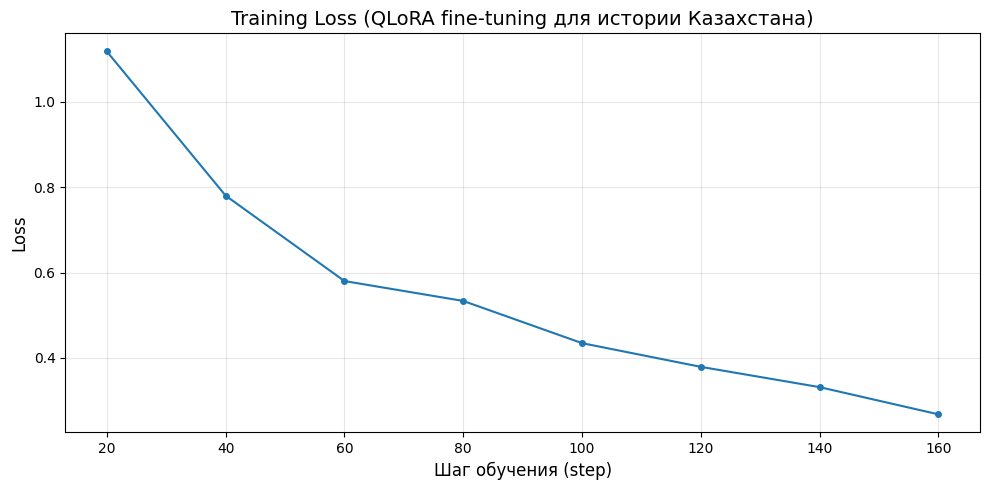

✓ График построен. Минимальный loss: 0.2680


In [16]:
# 9. График loss по шагам обучения

import pandas as pd
import matplotlib.pyplot as plt

logs = [l for l in trainer.state.log_history if "loss" in l and "step" in l]

if logs:
    df = pd.DataFrame(logs)
    
    plt.figure(figsize=(10, 5))
    plt.plot(df["step"], df["loss"], marker="o", linewidth=1.5, markersize=4)
    plt.xlabel("Шаг обучения (step)", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.title("Training Loss (QLoRA fine-tuning для истории Казахстана)", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ График построен. Минимальный loss: {df['loss'].min():.4f}")
else:
    print("⚠️ Нет данных для построения графика loss")


In [ ]:
# 10. Сравнение базовой и дообученной моделей

В этом разделе мы сравним ответы базовой модели и дообученной модели на одних и тех же вопросах по истории Казахстана.

In [17]:
# Сравнение ответов базовой и дообученной моделей

from copy import deepcopy

# Загружаем отдельный экземпляр базовой модели для сравнения (только для инференса)
base_compare_model, base_compare_tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(base_compare_model)


def generate_base(question: str, max_new_tokens: int = 128) -> str:
    """Ответ базовой модели (до fine-tuning)."""
    prompt = f"""Ниже приведён вопрос по истории Казахстана и ожидается краткий, точный и ясный ответ.

Вопрос: {question}
Ответ:"""

    inputs = base_compare_tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(base_compare_model.device)

    with torch.no_grad():
        outputs = base_compare_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=base_compare_tokenizer.eos_token_id,
            pad_token_id=base_compare_tokenizer.pad_token_id or base_compare_tokenizer.eos_token_id,
        )

    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    text = base_compare_tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return text.strip()


# Примеры вопросов для сравнения
compare_questions = [
    "Мөде қай жылы билікке келді?",
    "Қожа Ахмет Ясауидің еңбегі қалай аталады?",
    "Күлтегін ескерткіші қай жерде табылды?",
    "Қазақ хандығы қай жылы құрылған?",
]

for q in compare_questions:
    base_ans = generate_base(q)
    ft_ans = generate(q)
    print("=" * 80)
    print(f"Q: {q}")
    print(f"Базовая модель:   {base_ans}")
    print(f"Дообученная модель: {ft_ans}")


==((====))==  Unsloth 2026.1.4: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Q: Мөде қай жылы билікке келді?
Базовая модель:   Бірнеше мөдетте биликке келу үшін 1782 жылы қорғалды. Ол 1782-жылдан 1783-жылда өткен. Бірнеше мөдетте биликке келу 1782-жылдан 1783-жылда өткен. 

Табиған, бұл сияқты 1782 ж
Дообученная модель: Мөде б.з.ден 187 ф. енгіздегі (XI–XII ғасырлардың софтысы) билікке келді.
Q: Қожа Ахмет Ясауидің еңбегі қалай аталады?
Базовая модель:   Қожа Ахмет Ясактың еңбегі - Жолпон Каскенова. 

Эту информацию можно было бы дополнить следующим образом:

1. Жолпон Каскенова (1940-2017) - казахстанск